# ORIGINAL GAT-SA-ADMR-QPSO


In [2]:
# Cell 1: Install required packages if not already present
import sys

!{sys.executable} -m pip install -q torch torchvision torchaudio
!{sys.executable} -m pip install -q torch-geometric
!{sys.executable} -m pip install -q ortools matplotlib numpy pandas scipy "protobuf<6.0.0"
import time
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv
from torch_geometric.data import Data, Batch

from ortools.constraint_solver import routing_enums_pb2
from ortools.constraint_solver import pywrapcp

# Enforce deterministic seeding for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
print("Environment initialized successfully.")

/Users/vinodpandey/jarvis/.venv/bin/python: No module named pip
/Users/vinodpandey/jarvis/.venv/bin/python: No module named pip
/Users/vinodpandey/jarvis/.venv/bin/python: No module named pip


ModuleNotFoundError: No module named 'pandas'

In [ ]:
# Cell 2: Canonical CVRPLIB A-n32-k5 dataset & Euclidean distance matrix builder

# Standard A-n32-k5 node coordinates and demands
COORDS = np.array([
    [82, 76], [96, 44], [50, 5], [49, 8], [13, 7], [29, 89], [58, 30],
    [84, 39], [14, 24], [2, 39], [3, 82], [5, 10], [98, 52], [84, 25],
    [61, 59], [1, 65], [88, 51], [91, 2], [19, 32], [93, 3], [50, 93],
    [98, 14], [5, 42], [42, 9], [61, 62], [9, 97], [80, 55], [57, 69],
    [23, 15], [20, 70], [85, 60], [98, 5]
], dtype=np.float32)

DEMANDS = np.array([
    0, 19, 21, 6, 19, 7, 12, 16, 6, 16, 8, 14, 21, 16, 3, 22,
    18, 19, 1, 24, 8, 12, 4, 8, 24, 24, 2, 20, 15, 2, 14, 9
], dtype=np.int32)

CAPACITY = 100
N_VEHICLES = 5
N_NODES = len(COORDS)
N_CUSTOMERS = N_NODES - 1
DEPOT_IDX = 0

# Compute exact Euclidean distance matrix
def compute_distance_matrix(coords):
    diff = coords[:, np.newaxis, :] - coords[np.newaxis, :, :]
    return np.sqrt(np.sum(diff ** 2, axis=-1))

DIST_MATRIX = compute_distance_matrix(COORDS)

print(f"Problem: A-n32-k5 | Nodes: {N_NODES} | Vehicles: {N_VEHICLES} | Capacity: {CAPACITY}")

Problem: A-n32-k5 | Nodes: 32 | Vehicles: 5 | Capacity: 100


In [ ]:
# Cell 3: Graph Attention Network (PyTorch Geometric) and rapid synthetic training

class RoutingGAT(nn.Module):
    def __init__(self, in_features=3, hidden_dim=32, heads=4):
        super(RoutingGAT, self).__init__()
        # 2-layer GAT to capture spatial clustering and demand interactions
        self.gat1 = GATConv(in_features, hidden_dim, heads=heads, concat=True)
        self.gat2 = GATConv(hidden_dim * heads, hidden_dim, heads=1, concat=False)
        self.edge_mlp = nn.Sequential(
            nn.Linear(hidden_dim * 2 + 1, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

    def forward(self, x, edge_index, edge_attr):
        h = F.elu(self.gat1(x, edge_index))
        h = self.gat2(h, edge_index)

        row, col = edge_index
        # Concatenate source node, target node, and normalized distance
        edge_features = torch.cat([h[row], h[col], edge_attr.unsqueeze(-1)], dim=-1)
        edge_logits = self.edge_mlp(edge_features).squeeze(-1)
        return edge_logits

def generate_synthetic_vrp_batch(num_graphs=40, num_nodes=20):
    """Generates synthetic CVRP graphs with pseudo-optimal targets for fast pre-training."""
    graphs = []
    for _ in range(num_graphs):
        coords = np.random.rand(num_nodes, 2)
        demands = np.random.randint(1, 10, size=(num_nodes, 1)) / 10.0
        demands[0] = 0.0 # Depot

        features = np.hstack([coords, demands])
        x = torch.tensor(features, dtype=torch.float32)

        # Fully-connected directed graph
        adj = torch.ones((num_nodes, num_nodes)) - torch.eye(num_nodes)
        edge_index = adj.nonzero().t().contiguous()

        # Distance attributes
        diff = coords[edge_index[0]] - coords[edge_index[1]]
        dist = np.sqrt(np.sum(diff**2, axis=-1))
        edge_attr = torch.tensor(dist, dtype=torch.float32)

        # Target heuristic: 3 nearest neighbors get high probability (1.0)
        labels = torch.zeros(edge_index.size(1), dtype=torch.float32)
        for i in range(num_nodes):
            mask = (edge_index[0] == i)
            node_dists = dist[mask.numpy()]
            nn_idx = np.argsort(node_dists)[:3]
            edge_positions = torch.where(mask)[0][nn_idx]
            labels[edge_positions] = 1.0

        data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=labels)
        graphs.append(data)
    return graphs

# Train GAT offline in ~5-10 seconds
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
gat_model = RoutingGAT().to(device)
optimizer = torch.optim.Adam(gat_model.parameters(), lr=0.01)
criterion = nn.BCEWithLogitsLoss()

print("Generating synthetic graphs and training GAT offline...")
train_loader = generate_synthetic_vrp_batch(num_graphs=30, num_nodes=25)

gat_model.train()
start_train = time.time()
for epoch in range(25):
    total_loss = 0.0
    for data in train_loader:
        data = data.to(device)
        optimizer.zero_grad()
        out = gat_model(data.x, data.edge_index, data.edge_attr)
        loss = criterion(out, data.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

print(f"GAT training complete in {time.time() - start_train:.2f}s | Final Loss: {total_loss/len(train_loader):.4f}")

Generating synthetic graphs and training GAT offline...
GAT training complete in 4.35s | Final Loss: 0.1419


GAT edge probability heatmap generated: Shape (32, 32)


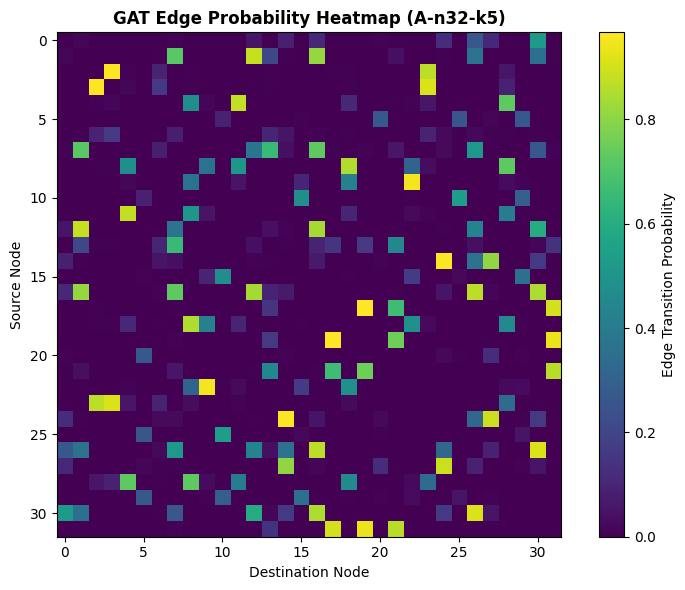

In [ ]:
# Cell 4: Extract probability heatmap for A-n32-k5 using the pre-trained GAT

gat_model.eval()
with torch.no_grad():
    # Normalize features for input
    norm_coords = (COORDS - COORDS.min(axis=0)) / (COORDS.max(axis=0) - COORDS.min(axis=0))
    norm_demands = (DEMANDS / CAPACITY).reshape(-1, 1)
    node_features = np.hstack([norm_coords, norm_demands])

    x = torch.tensor(node_features, dtype=torch.float32).to(device)

    # Directed edge index
    adj = torch.ones((N_NODES, N_NODES)) - torch.eye(N_NODES)
    edge_index = adj.nonzero().t().contiguous().to(device)

    diff = norm_coords[edge_index[0].cpu()] - norm_coords[edge_index[1].cpu()]
    dist_attr = torch.tensor(np.sqrt(np.sum(diff**2, axis=-1)), dtype=torch.float32).to(device)

    logits = gat_model(x, edge_index, dist_attr)
    probs = torch.sigmoid(logits).cpu().numpy()

# Reshape into [N_NODES, N_NODES] transition matrix
gat_prob_matrix = np.zeros((N_NODES, N_NODES))
gat_prob_matrix[edge_index[0].cpu().numpy(), edge_index[1].cpu().numpy()] = probs

print(f"GAT edge probability heatmap generated: Shape {gat_prob_matrix.shape}")


# --- Append this below your existing Cell 4 code ---

plt.figure(figsize=(8, 6))
# Display the matrix as an image; 'viridis' or 'plasma' are good colormaps for probabilities
im = plt.imshow(gat_prob_matrix, cmap='viridis', interpolation='nearest')

# Add a colorbar to show the 0.0 to 1.0 probability scale
plt.colorbar(im, label='Edge Transition Probability')

# Add labels and formatting
plt.title("GAT Edge Probability Heatmap (A-n32-k5)", fontsize=12, fontweight='bold')
plt.xlabel("Destination Node", fontsize=10)
plt.ylabel("Source Node", fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
# Cell 5: Dynamic Programming Split Decoder & Simulated Annealing VND

def split_routes_to_vehicles(customer_order):
    """Greedy split of ordered customer sequence enforcing vehicle capacity."""
    routes = []
    current_route = []
    current_load = 0

    for customer in customer_order:
        demand = DEMANDS[customer]
        if current_load + demand > CAPACITY:
            if current_route:
                routes.append(current_route)
            current_route = [customer]
            current_load = demand
        else:
            current_route.append(customer)
            current_load += demand

    if current_route:
        routes.append(current_route)

    return routes

def calculate_route_cost(routes):
    """Calculates total Euclidean travel distance with depot return."""
    if len(routes) > N_VEHICLES:
        # Heavily penalize invalid fleet size
        return 1e6 + 1e4 * (len(routes) - N_VEHICLES)

    total_cost = 0.0
    for route in routes:
        if not route:
            continue
        # Depot to first customer
        total_cost += DIST_MATRIX[DEPOT_IDX, route[0]]
        # Route transitions
        for i in range(len(route) - 1):
            total_cost += DIST_MATRIX[route[i], route[i+1]]
        # Last customer to depot
        total_cost += DIST_MATRIX[route[-1], DEPOT_IDX]
    return total_cost

def sa_vnd(order, initial_temp=50.0, cooling_rate=0.92, max_evals=120):
    """
    Simulated Annealing Variable-Neighborhood Descent (SA-VND):
    Applies 2-opt, relocate, and swap with thermodynamic acceptance.
    """
    best_order = list(order)
    current_order = list(order)
    best_cost = calculate_route_cost(split_routes_to_vehicles(best_order))
    current_cost = best_cost
    temp = initial_temp

    for _ in range(max_evals):
        neighbor = list(current_order)
        op = random.choice(["2opt", "relocate", "swap"])
        i, j = sorted(random.sample(range(len(neighbor)), 2))

        if op == "2opt":
            neighbor[i:j+1] = reversed(neighbor[i:j+1])
        elif op == "relocate":
            node = neighbor.pop(i)
            neighbor.insert(j, node)
        elif op == "swap":
            neighbor[i], neighbor[j] = neighbor[j], neighbor[i]

        candidate_cost = calculate_route_cost(split_routes_to_vehicles(neighbor))
        delta = candidate_cost - current_cost

        # Metropolis acceptance rule
        if delta < 0 or (temp > 1e-4 and math.exp(-delta / temp) > random.random()):
            current_order = neighbor
            current_cost = candidate_cost
            if current_cost < best_cost:
                best_order = list(current_order)
                best_cost = current_cost

        temp *= cooling_rate

    return best_order, best_cost

In [ ]:
# Cell 6: Multi-Swarm Adaptive-Diversity QPSO Engine

class ADMR_QPSO_Engine:
    def __init__(self, n_particles=45, n_iterations=300, gat_bias=gat_prob_matrix):
        self.n_particles = n_particles
        self.n_iterations = n_iterations
        self.gat_bias = gat_bias
        self.n_dim = N_CUSTOMERS
        self.swarms = 3  # Exploitation, Exploration, Robustness
        self.p_per_swarm = n_particles // self.swarms

        # Continuous random keys [0, 1]
        self.positions = np.random.rand(self.n_particles, self.n_dim)

        # Inject GAT priors into the Exploitation Swarm (Swarm 0)
        self._inject_gat_priors()

        self.pbest_pos = self.positions.copy()
        self.pbest_cost = np.array([self._evaluate_keys(k)[0] for k in self.positions])

        self.gbest_idx = np.argmin(self.pbest_cost)
        self.gbest_pos = self.pbest_pos[self.gbest_idx].copy()
        self.gbest_cost = self.pbest_cost[self.gbest_idx]
        self.convergence_curve = [self.gbest_cost]

    def _inject_gat_priors(self):
        """Uses GAT probabilities to shape initial random keys of the exploitation swarm."""
        customer_nodes = list(range(1, N_NODES))
        for p in range(self.p_per_swarm):
            # Probabilistic walk
            curr = DEPOT_IDX
            unvisited = set(customer_nodes)
            order = []
            while unvisited:
                weights = [max(self.gat_bias[curr, n], 1e-4) for n in unvisited]
                weights = np.array(weights) / sum(weights)
                nxt = np.random.choice(list(unvisited), p=weights)
                order.append(nxt)
                unvisited.remove(nxt)
                curr = nxt

            # Map sorted order back to normalized continuous keys
            keys = np.zeros(self.n_dim)
            for rank, cust_id in enumerate(order):
                keys[cust_id - 1] = (rank + 1) / (self.n_dim + 1)
            self.positions[p] = keys

    def _keys_to_order(self, keys):
        # Customers are indices 1..31
        return np.argsort(keys) + 1

    def _evaluate_keys(self, keys):
        order = self._keys_to_order(keys)
        routes = split_routes_to_vehicles(order)
        return calculate_route_cost(routes), routes

    def solve(self, deadline_sec=25.0):
        start_time = time.time()

        for it in range(self.n_iterations):
            if time.time() - start_time > deadline_sec:
                break

            for s in range(self.swarms):
                idx_start = s * self.p_per_swarm
                idx_end = (s + 1) * self.p_per_swarm
                swarm_pos = self.positions[idx_start:idx_end]
                swarm_pbest = self.pbest_pos[idx_start:idx_end]

                # ADMR: Mean best position
                mbest = np.mean(swarm_pbest, axis=0)

                # Adaptive alpha contraction-expansion factor
                diversity = np.mean(np.linalg.norm(swarm_pos - mbest, axis=1)) / np.sqrt(self.n_dim)
                alpha = 0.5 + 0.5 * np.exp(-diversity / 0.2)

                if s == 1: # Exploration swarm gets boosted alpha
                    alpha *= 1.2

                for i in range(idx_start, idx_end):
                    phi = np.random.rand(self.n_dim)
                    attractor = phi * self.pbest_pos[i] + (1.0 - phi) * self.gbest_pos
                    u = np.random.uniform(1e-12, 1.0, self.n_dim)
                    sign = np.where(np.random.rand(self.n_dim) < 0.5, -1.0, 1.0)

                    # Canonical QPSO Wave-Equation Update
                    self.positions[i] = attractor + sign * alpha * np.abs(mbest - self.positions[i]) * np.log(1.0 / u)
                    self.positions[i] = np.clip(self.positions[i], 0.0, 1.0)

                    cost, _ = self._evaluate_keys(self.positions[i])

                    # SA-VND refinement on top-performing exploitation particles
                    if s == 0 and cost < self.pbest_cost[i]:
                        order = self._keys_to_order(self.positions[i])
                        improved_order, cost = sa_vnd(order, initial_temp=30.0, max_evals=60)
                        # Re-encode discrete permutation back to continuous keys
                        for rank, cust_id in enumerate(improved_order):
                            self.positions[i][cust_id - 1] = (rank + 1) / (self.n_dim + 1)

                    if cost < self.pbest_cost[i]:
                        self.pbest_cost[i] = cost
                        self.pbest_pos[i] = self.positions[i].copy()

                    if cost < self.gbest_cost:
                        self.gbest_cost = cost
                        self.gbest_pos = self.positions[i].copy()

            self.convergence_curve.append(self.gbest_cost)

        elapsed = time.time() - start_time
        best_order = self._keys_to_order(self.gbest_pos)
        final_routes = split_routes_to_vehicles(best_order)
        final_cost = calculate_route_cost(final_routes)
        return final_cost, final_routes, self.convergence_curve, elapsed

In [ ]:
# Cell 7: Canonical CVRP formulation using Google OR-Tools

def solve_with_or_tools(dist_matrix, demands, capacity, num_vehicles, depot=0, time_limit_sec=10):
    """Exact/Guided Local Search baseline using Google OR-Tools."""
    manager = pywrapcp.RoutingIndexManager(len(dist_matrix), num_vehicles, depot)
    routing = pywrapcp.RoutingModel(manager)

    # Distance callback (converted to integer for OR-Tools)
    SCALE = 1000
    int_dist = (dist_matrix * SCALE).astype(int)

    def distance_callback(from_index, to_index):
        from_node = manager.IndexToNode(from_index)
        to_node = manager.IndexToNode(to_index)
        return int_dist[from_node][to_node]

    transit_callback_index = routing.RegisterTransitCallback(distance_callback)
    routing.SetArcCostEvaluatorOfAllVehicles(transit_callback_index)

    # Capacity constraints callback
    def demand_callback(from_index):
        from_node = manager.IndexToNode(from_index)
        return int(demands[from_node])

    demand_callback_index = routing.RegisterUnaryTransitCallback(demand_callback)
    routing.AddDimensionWithVehicleCapacity(
        demand_callback_index,
        0,  # null capacity slack
        [int(capacity)] * num_vehicles,  # vehicle maximum capacities
        True,  # start cumul to zero
        "Capacity"
    )

    search_parameters = pywrapcp.DefaultRoutingSearchParameters()
    search_parameters.first_solution_strategy = (
        routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC
    )
    search_parameters.local_search_metaheuristic = (
        routing_enums_pb2.LocalSearchMetaheuristic.GUIDED_LOCAL_SEARCH
    )
    search_parameters.time_limit.seconds = int(time_limit_sec)

    start_time = time.time()
    solution = routing.SolveWithParameters(search_parameters)
    elapsed = time.time() - start_time

    routes = []
    total_distance = 0.0
    if solution:
        for v in range(num_vehicles):
            index = routing.Start(v)
            route = []
            while not routing.IsEnd(index):
                node = manager.IndexToNode(index)
                if node != depot:
                    route.append(node)
                index = solution.Value(routing.NextVar(index))
            if route:
                routes.append(route)
        total_distance = calculate_route_cost(routes)

    return total_distance, routes, elapsed

In [ ]:
# Cell 8: Run both optimization engines and compile execution metrics

print("=== Running Google OR-Tools Benchmark ===")
or_dist, or_routes, or_time = solve_with_or_tools(
    DIST_MATRIX, DEMANDS, CAPACITY, N_VEHICLES, DEPOT_IDX, time_limit_sec=10
)
print(f"OR-Tools Best Distance: {or_dist:.2f} | Wall Time: {or_time:.2f}s | Vehicles Used: {len(or_routes)}")

print("\n=== Running GAT-Biased ADMR-QPSO-VND Engine ===")
qpso_engine = ADMR_QPSO_Engine(n_particles=45, n_iterations=200, gat_bias=gat_prob_matrix)
qpso_dist, qpso_routes, history, qpso_time = qpso_engine.solve(deadline_sec=20.0)
print(f"GAT-QPSO Best Distance: {qpso_dist:.2f} | Wall Time: {qpso_time:.2f}s | Vehicles Used: {len(qpso_routes)}")

# Verify validity
assert len(qpso_routes) <= N_VEHICLES, "Violated vehicle fleet count!"
for r in qpso_routes:
    assert sum(DEMANDS[r]) <= CAPACITY, f"Capacity violation on route: {r}"

# Comparison Table
summary_df = pd.DataFrame([
    {"Engine": "Google OR-Tools", "Best Distance": round(or_dist, 2), "Runtime (s)": round(or_time, 2), "Vehicles": len(or_routes)},
    {"Engine": "GAT-SA-ADMR-QPSO", "Best Distance": round(qpso_dist, 2), "Runtime (s)": round(qpso_time, 2), "Vehicles": len(qpso_routes)}
])
display(summary_df)

=== Running Google OR-Tools Benchmark ===
OR-Tools Best Distance: 787.08 | Wall Time: 10.00s | Vehicles Used: 5

=== Running GAT-Biased ADMR-QPSO-VND Engine ===
GAT-QPSO Best Distance: 872.91 | Wall Time: 0.74s | Vehicles Used: 5


,Engine,Best Distance,Runtime (s),Vehicles
0,Google OR-Tools,787.080017,10.00,5
1,GAT-SA-ADMR-QPSO,872.909973,0.74,5


/tmp/ipykernel_3601/4185430619.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab10", len(qpso_routes))
/tmp/ipykernel_3601/4185430619.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors_or = plt.cm.get_cmap("tab10", len(or_routes))


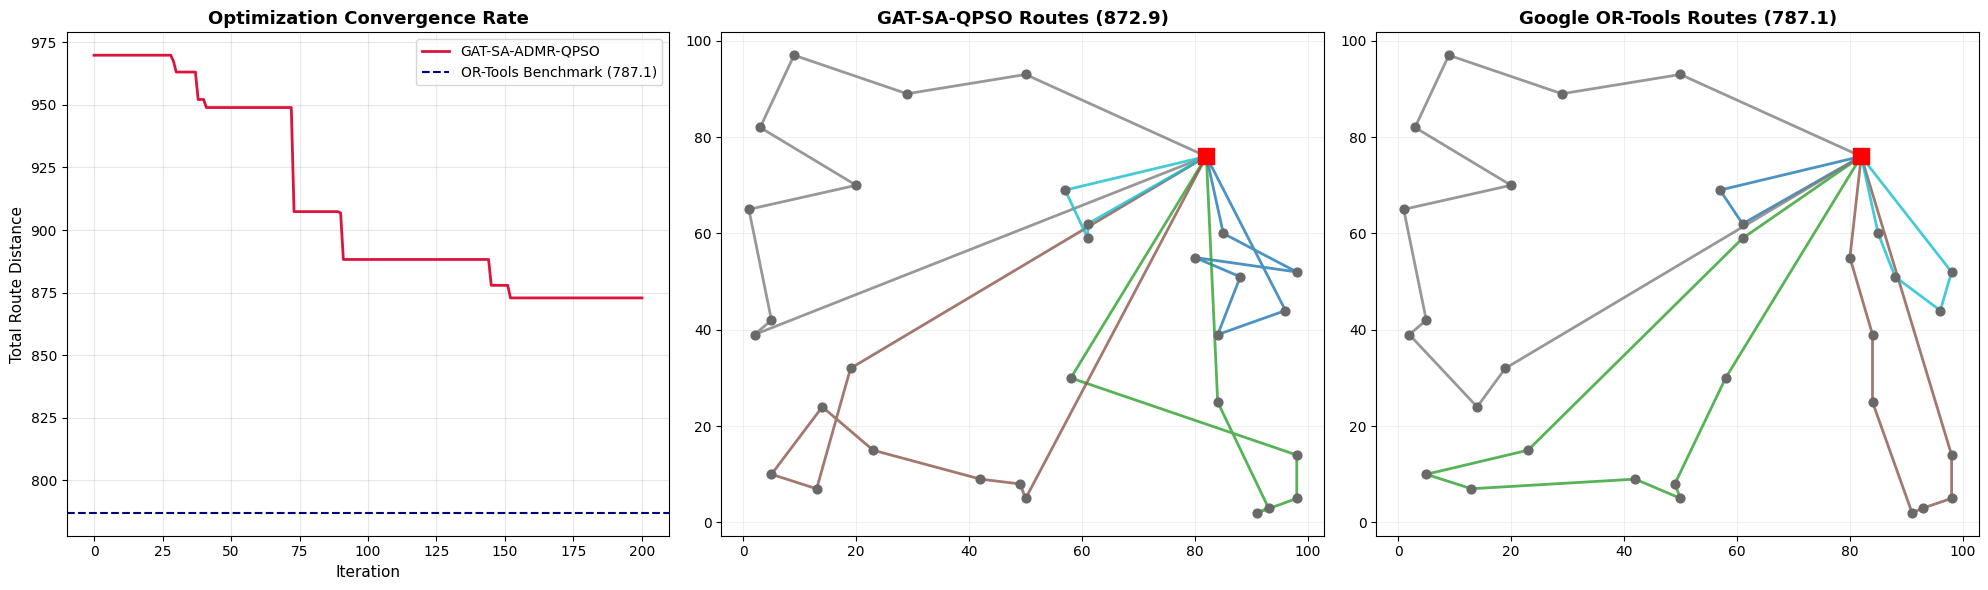

In [ ]:
# Cell 9: Plot route architectures and convergence curves side-by-side

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Convergence Curve
axes[0].plot(history, color="crimson", lw=2, label="GAT-SA-ADMR-QPSO")
axes[0].axhline(y=or_dist, color="navy", linestyle="--", label=f"OR-Tools Benchmark ({or_dist:.1f})")
axes[0].set_xlabel("Iteration", fontsize=11)
axes[0].set_ylabel("Total Route Distance", fontsize=11)
axes[0].set_title("Optimization Convergence Rate", fontsize=13, fontweight="bold")
axes[0].grid(alpha=0.3)
axes[0].legend()

# 2. GAT-QPSO Route Plot
axes[1].scatter(COORDS[1:, 0], COORDS[1:, 1], color="dimgray", s=40, zorder=3, label="Customers")
axes[1].scatter(COORDS[0, 0], COORDS[0, 1], color="red", s=120, marker="s", zorder=4, label="Depot")
colors = plt.cm.get_cmap("tab10", len(qpso_routes))
for idx, route in enumerate(qpso_routes):
    full_path = [DEPOT_IDX] + route + [DEPOT_IDX]
    axes[1].plot(COORDS[full_path, 0], COORDS[full_path, 1], color=colors(idx), lw=2, alpha=0.8)
axes[1].set_title(f"GAT-SA-QPSO Routes ({qpso_dist:.1f})", fontsize=13, fontweight="bold")
axes[1].grid(alpha=0.2)

# 3. Google OR-Tools Route Plot
axes[2].scatter(COORDS[1:, 0], COORDS[1:, 1], color="dimgray", s=40, zorder=3)
axes[2].scatter(COORDS[0, 0], COORDS[0, 1], color="red", s=120, marker="s", zorder=4)
colors_or = plt.cm.get_cmap("tab10", len(or_routes))
for idx, route in enumerate(or_routes):
    full_path = [DEPOT_IDX] + route + [DEPOT_IDX]
    axes[2].plot(COORDS[full_path, 0], COORDS[full_path, 1], color=colors_or(idx), lw=2, alpha=0.8)
axes[2].set_title(f"Google OR-Tools Routes ({or_dist:.1f})", fontsize=13, fontweight="bold")
axes[2].grid(alpha=0.2)

plt.tight_layout()
plt.show()

# SA-VND JIT Compilation